In [1]:
# /// script
# require-python = ">=3.13"
# dependencies = ["azure-ai-inference", "duckdb", "ipywidgets==8.1.8", "jupysql", "python-dotenv", "timc-vector-toolkit", "tokenizers", "toml", "zstandard"]
# ///

# Number of events by processes

We go here for counting the events that occurred under the "responsibility" of each process instance,
split by type.

In [2]:
import duckdb
import logging as lg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm, trange
import warnings

In [3]:
tqdm.pandas()

In [4]:
lg.basicConfig(level=lg.INFO, format="%(asctime)-8s | %(levelname)-8s | %(name)-24s | %(message)s", datefmt="%H:%M:%S")
LOG = lg.getLogger("notebook")

In [5]:
pd.set_option("display.html.use_mathjax", False)
pd.set_option("display.max_colWidth", None)
pd.set_option("display.min_rows", 20)
pd.set_option("styler.html.mathjax", False)

In [6]:
root_acme4 = Path("/data/ACME4/stdview-20240819-20240923")  # Replace with your own data location!
db = duckdb.connect()
for path in root_acme4.glob("*.parquet"):
    name_view = path.with_suffix("").name
    LOG.debug(f"Add view {name_view} over {path}")
    db.sql(f"create or replace view {name_view} as select * from '{path}'")

In [7]:
with warnings.catch_warnings(action="ignore", category=SyntaxWarning):
    %load_ext sql
%sql db --alias duckdb
%config SqlMagic.displaycon=False
%config SqlMagic.autopandas=True

Tip: You may define configurations in /work/home/hamelin/Wintap-Analytics/2025-acme4-explore/pyproject.toml or /work/home/hamelin/.jupysql/config.

Did not find user configurations in /work/home/hamelin/Wintap-Analytics/2025-acme4-explore/pyproject.toml.

ACME4 carries 5 tables events:

| Parquet file name$^1$| Event type |
|---------------------:|:-----------|
| `process`            | Subprocess spawns. |
| `process_file`       | File operations (read/write). |
| `process_image_load` | Object code image (DLL) load events. |
| `process_net_conn`   | Network transactions. |
| `process_registry`   | Windows Registry operations. |

$^1$ Less its `.parquet` extension.

So we count events across each of these tables and merge the results.

In [8]:
%%sql num_events <<
select
    pid_hash,
    sum(num_subprocs) as num_subprocs,
    sum(num_fileops) as num_fileops,
    sum(num_image_loads) as num_image_loads,
    sum(num_netops) as num_netops,
    sum(num_regops) as num_regops
from (
    (
        select parent_pid_hash as pid_hash, count(distinct pid_hash) as num_subprocs, 0 as num_fileops, 0 as num_image_loads, 0 as num_netops, 0 as num_regops
        from process
        group by parent_pid_hash
        having parent_pid_hash not null
    )
    union
    (
        select pid_hash, 0 as num_subprocs, count(file_id) as num_fileops, 0 as num_image_loads, 0 as num_netops, 0 as num_regops
        from process_file
        group by pid_hash
    )
    union
    (
        select pid_hash, 0 as num_subprocs, 0 as num_fileops, count(file_id) as num_image_loads, 0 as num_netops, 0 as num_regops
        from process_image_load
        group by pid_hash
    )
    union
    (
        select pid_hash, 0 as num_subprocs, 0 as num_fileops, 0 as num_image_loads, count(conn_id) as num_netops, 0 as num_regops
        from process_net_conn
        group by pid_hash
    )
    union
    (
        select pid_hash, 0 as num_subprocs, 0 as num_fileops, 0 as num_image_loads, 0 as num_netops, count(reg_path) as num_regops
        from process_registry
        group by pid_hash
    )
) as E
group by pid_hash
order by pid_hash

In [9]:
num_events

,pid_hash,num_subprocs,num_fileops,num_image_loads,num_netops,num_regops
0,000001EA39466E3FB91366E47D7C96C9,0.0,0.0,27.0,0.0,0.0
1,0000080A4A4B72EB64060CC37970EEC3,0.0,0.0,0.0,0.0,101.0
2,00000CE18D05E89D614D0C0C0E6F271B,1.0,5.0,0.0,0.0,37.0
3,00000F8E6D0244A31216546667930CCF,0.0,0.0,27.0,0.0,106.0
4,0000104662DB3876762DA1389262FE6C,1.0,0.0,0.0,0.0,0.0
5,00001090E26E92E0DC520BDC7503142B,0.0,0.0,27.0,0.0,26.0
6,000013026EDA0CF8251D76C00515141D,1.0,0.0,0.0,0.0,0.0
7,000018C6D284BC9A337CC0DF0297B701,1.0,0.0,0.0,0.0,0.0
8,00002197F7C3301007F5ABDF258B9255,1.0,0.0,0.0,0.0,0.0
9,0000251FFF585B0D0596C9C802C836E0,0.0,0.0,27.0,0.0,0.0


Here's a weird quirk of this dataset.
The `process` table is supposed to carry the metadata for each process accounted for in the dataset.
However, it seems that we only have that metdata for a bit less than 60% of the process instances.
Call these the _known processes_.

In [12]:
%%sql processes_known <<
select num_events.pid_hash, process.parent_pid_hash
from num_events
inner join process using (pid_hash)
order by pid_hash

In [13]:
processes_known

,pid_hash,parent_pid_hash
0,000001EA39466E3FB91366E47D7C96C9,BCB15597D6E1D4B42DF4EB7622D41E4E
1,00000CE18D05E89D614D0C0C0E6F271B,0A83EBDD6CC4FF480D1844ACB0C556E6
2,00000F8E6D0244A31216546667930CCF,95ACC45F35020D92C6EA1234CAE537B6
3,0000251FFF585B0D0596C9C802C836E0,2B783923CD89D667E60326B60B30E17D
4,0000312235C982867A2485C9BA3AEC3E,7DC78F8073B337781375D05C663FB88A
5,00003950B4ECD7AC9F9A52DA67364420,9784855246BD4880830F1C3BB5208359
6,00003CC07783940FA07B41C1035F6B81,C88C1A1614231EA746249FA58F6AF8E7
7,00003F4B8A5DEDE7C2F4E4C73668DC45,96A9A9E0724A06CD25AB93EA929B6075
8,000053D80ECB0D8B96A4120C921D306C,42695F2FD53320733A65DD64FCB6B194
9,000054CB8DDF30830BBD0777F891E67E,69041A032E0A7907F975017D161F65C9


A small number of these don't even have a parent process!
Hello sensor noise.

In [19]:
%%sql
select count(*) as num_processes
from processes_known
where parent_pid_hash is null

,num_processes
0,12043


The complement of the known processes are the _unknown processes_.

In [23]:
%%sql processes_unknown <<
select *
from num_events
anti join processes_known using (pid_hash)
order by pid_hash

In [24]:
processes_unknown

,pid_hash,num_subprocs,num_fileops,num_image_loads,num_netops,num_regops
0,0000080A4A4B72EB64060CC37970EEC3,0.0,0.0,0.0,0.0,101.0
1,0000104662DB3876762DA1389262FE6C,1.0,0.0,0.0,0.0,0.0
2,00001090E26E92E0DC520BDC7503142B,0.0,0.0,27.0,0.0,26.0
3,000013026EDA0CF8251D76C00515141D,1.0,0.0,0.0,0.0,0.0
4,000018C6D284BC9A337CC0DF0297B701,1.0,0.0,0.0,0.0,0.0
5,00002197F7C3301007F5ABDF258B9255,1.0,0.0,0.0,0.0,0.0
6,000028C42C1B0E67461E02050FAE5AC5,1.0,0.0,0.0,0.0,0.0
7,0000317ECA7C7D5D4E0E00FF28E1A5EE,1.0,0.0,0.0,0.0,0.0
8,00003282BB960DE35D6F13F6EA94F56B,1.0,0.0,0.0,0.0,0.0
9,00003B9BCF28DD1F2BF5A952D5013071,1.0,0.0,0.0,0.0,0.0


To capture an overview of the number of events per process, let's look at the distribution.
The following histograms show how many processes are described by any given number of events,
on a log-log scale.
By construction, the minimum number of events is 1;
the most active process generated some half a million events.

<Figure size 1200x400 with 0 Axes>

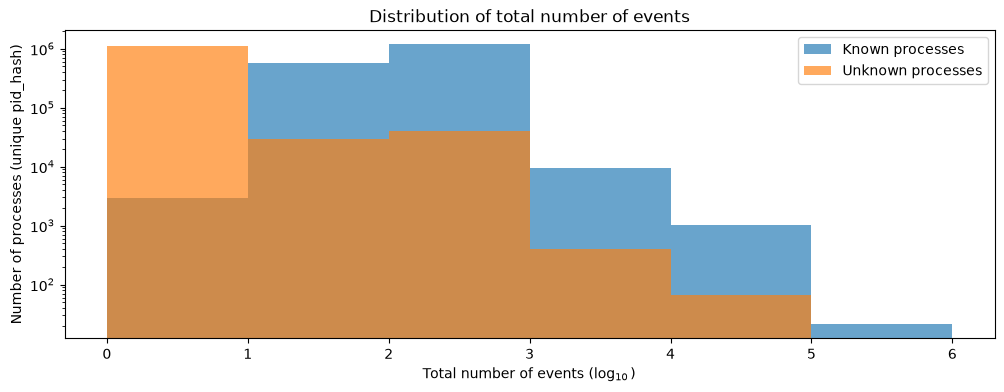

In [90]:
plt.figure(figsize=(12, 4))
total_events = num_events.set_index("pid_hash").sum(axis="columns")
max_events = np.ceil(np.log10(total_events.max()))
x = np.logspace(start=0, stop=max_events, num=int(max_events) + 1)
plt.figure(figsize=(12, 4))
plt.title("")
for selector in [processes_known, processes_unknown]:
    h, _ = np.histogram(total_events.loc[selector["pid_hash"]], bins=x)
    plt.bar((np.log10(x) + .5)[:-1], h, width=1., alpha=.67)
plt.yscale("log")
plt.title('Distribution of total number of events')
plt.legend(["Known processes", "Unknown processes"])
plt.xlabel(r"Total number of events ($\log_{10}$)")
plt.ylabel("Number of processes (unique pid_hash)")
None

Unknown processes generate visibly a lesser volume of events than known ones,
but their volume is definitely not negligible.

Let's look at a finer-granularity breakdown of event volumes by type,
restricted to known processes.

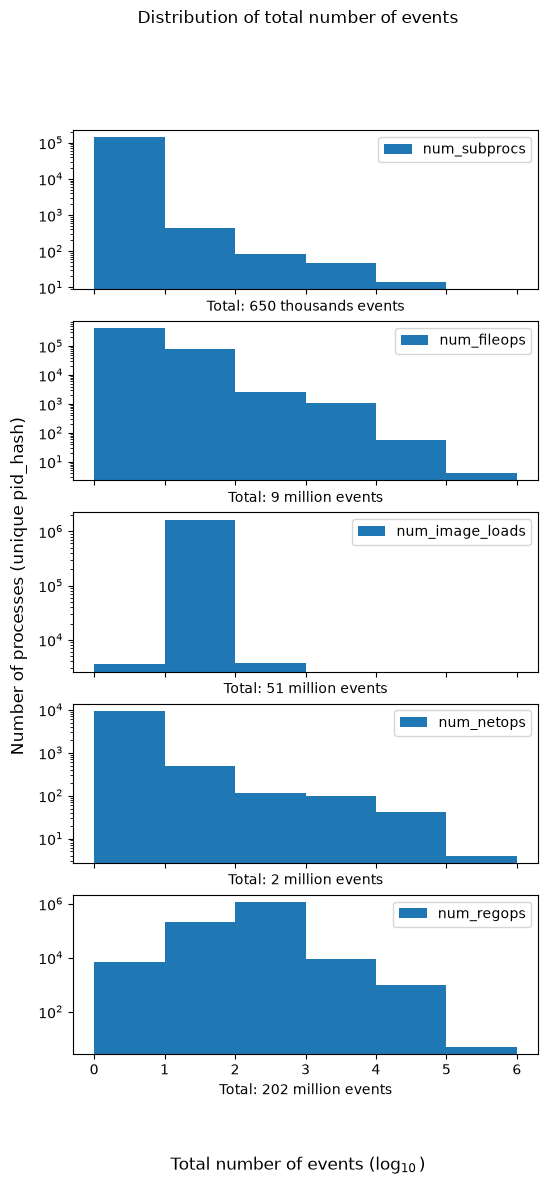

In [108]:
fig, ax = plt.subplots(5, 1, figsize=(6, 12), sharex=True)
nev_known = num_events.merge(processes_known, on="pid_hash", how="inner")
for i, col in enumerate("num_subprocs	num_fileops	num_image_loads	num_netops	num_regops".split()):
    h, _ = np.histogram(nev_known[col], bins=x)
    ax[i].bar((np.log10(x) + .5)[:-1], h, width=1.)
    ax[i].set_yscale("log")
    num_events = float(nev_known[col].sum())
    for units in ["events", "thousands events", "million events", "billion events", "trillion events"]:
        if num_events < 1000.:
            break
        num_events /= 1000.
    ax[i].set_xlabel(f"Total: {num_events:.0f} {units}")
    ax[i].legend([col])
fig.suptitle('Distribution of total number of events')
fig.supylabel("Number of processes (unique pid_hash)")
fig.supxlabel(r"Total number of events ($\log_{10}$)")
None